In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score

import os
os.chdir(r"C:\Users\ANWESHA BANERJEE\Desktop\projects")

In [9]:
# STEP 1: Loading & Cleaning DATA
print("1. Loading dataset...")
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# Drop unique identifier column (doesn't help prediction)
if 'customer_id' in df.columns:
    df = df.drop(columns=['customer_id'])

# Encode categorical text columns ('country' and 'gender') into numbers -> Country: France 0, Germany 1, Spain 2; Gender: Female 0, Male 1
label_encoders = {}
for col in ['country', 'gender']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("Data preview:")
print(df.head())

1. Loading dataset...
Data preview:
   credit_score  country  gender  age  tenure    balance  products_number  \
0           619        0       0   42       2       0.00                1   
1           608        2       0   41       1   83807.86                1   
2           502        0       0   42       8  159660.80                3   
3           699        0       0   39       1       0.00                2   
4           850        2       0   43       2  125510.82                1   

   credit_card  active_member  estimated_salary  churn  
0            1              1         101348.88      1  
1            0              1         112542.58      0  
2            1              0         113931.57      1  
3            0              0          93826.63      0  
4            1              1          79084.10      0  


In [11]:
#STEP 2: TRAIN BASELINE MODELS (FULL DATA)

print("2. Training Baseline Models...")

# 1. Separating Features (X) and Target (y)
X_full = df.drop(columns=['churn'])
y = df['churn']

# 2. Spliting data: 80% for training, 20% for testing (0.2)
X_train_a, X_test_a, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Scaling numeric features so algorithms learn properly
scaler = StandardScaler()
X_train_a_scaled = scaler.fit_transform(X_train_a)
X_test_a_scaled = scaler.transform(X_test_a)

# 4. Using the 3 models
models_a = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

# 5. Train each model and calculate performance
baseline_results = {}

for name, model in models_a.items():
    # Train
    model.fit(X_train_a_scaled, y_train)
    
    # Predict probabilities for ROC-AUC
    probs = model.predict_proba(X_test_a_scaled)[:, 1]
    
    # Calculate scores
    acc = model.score(X_test_a_scaled, y_test)
    auc = roc_auc_score(y_test, probs)
    
    # Save results
    baseline_results[name] = {'Accuracy': acc, 'AUC': auc, 'Probs': probs}
    print(f"-> {name:<18} | Accuracy: {acc:.4f} | ROC-AUC: {auc:.4f}")

2. Training Baseline Models...
-> Random Forest      | Accuracy: 0.8645 | ROC-AUC: 0.8469
-> Gradient Boosting  | Accuracy: 0.8675 | ROC-AUC: 0.8673
-> SVM                | Accuracy: 0.8560 | ROC-AUC: 0.8218


In [12]:
# STEP 3: TRAIN UNBIASED MODELS & COMPARE

print("3. Training Unbiased Models (No Demographics)...")

# 1. Removing country and gender from features
X_unbiased = df.drop(columns=['churn', 'country', 'gender'])

# 2. Split data: 80% train / 20% test
X_train_b, X_test_b, y_train, y_test = train_test_split(
    X_unbiased, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Scale unbiased numeric features
scaler_b = StandardScaler()
X_train_b_scaled = scaler_b.fit_transform(X_train_b)
X_test_b_scaled = scaler_b.transform(X_test_b)

# 4. Define the same 3 models
models_b = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

unbiased_results = {}

# 5. Train each unbiased model
for name, model in models_b.items():
    model.fit(X_train_b_scaled, y_train)
    
    probs = model.predict_proba(X_test_b_scaled)[:, 1]
    acc = model.score(X_test_b_scaled, y_test)
    auc = roc_auc_score(y_test, probs)
    
    unbiased_results[name] = {'Accuracy': acc, 'AUC': auc}

# ==========================================
# SIDE-BY-SIDE COMPARISON TABLE
# ==========================================
print("\n" + "=" * 65)
print("              FAIRNESS EXPERIMENT SUMMARY RESULTS               ")
print("=" * 65)
print(f"{'Model':<18} | {'Baseline AUC':<12} | {'Unbiased AUC':<12} | {'AUC Delta':<10}")
print("-" * 65)

for name in models_a.keys():
    base_auc = baseline_results[name]['AUC']
    unb_auc = unbiased_results[name]['AUC']
    delta = unb_auc - base_auc
    print(f"{name:<18} | {base_auc:<12.4f} | {unb_auc:<12.4f} | {delta:+.4f}")

print("=" * 65)

3. Training Unbiased Models (No Demographics)...

              FAIRNESS EXPERIMENT SUMMARY RESULTS               
Model              | Baseline AUC | Unbiased AUC | AUC Delta 
-----------------------------------------------------------------
Random Forest      | 0.8469       | 0.8274       | -0.0195
Gradient Boosting  | 0.8673       | 0.8547       | -0.0126
SVM                | 0.8218       | 0.7853       | -0.0365


4. Feature Importance Analysis (Gradient Boosting)...


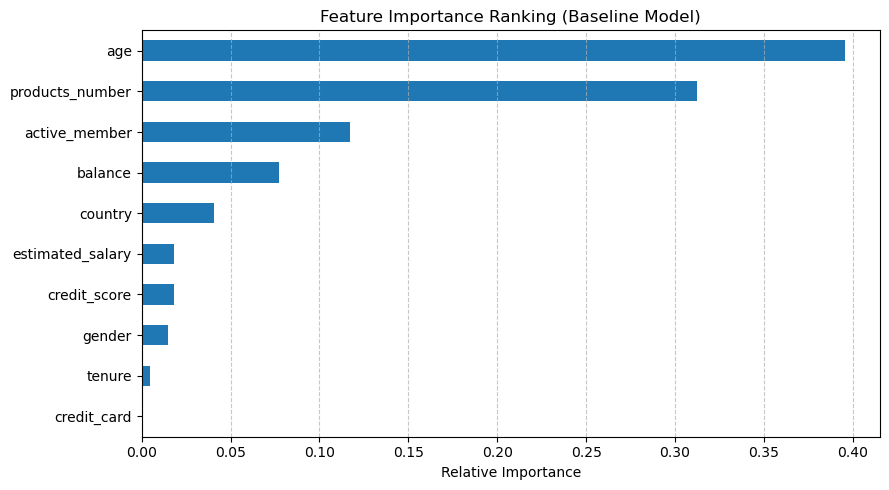


Exact Feature Importance Breakdown:
         Feature  Importance (%)
             age           39.55
 products_number           31.26
   active_member           11.73
         balance            7.74
         country            4.07
    credit_score            1.82
estimated_salary            1.82
          gender            1.47
          tenure            0.47
     credit_card            0.07


In [13]:
# STEP 4: FEATURE IMPORTANCE ANALYSIS
print("4. Feature Importance Analysis (Gradient Boosting)...")

# Extract feature importances from the baseline Gradient Boosting model
gb_model = models_a['Gradient Boosting']
importances = pd.Series(gb_model.feature_importances_, index=X_full.columns)

# Sort and plot
plt.figure(figsize=(9, 5))
importances.sort_values().plot(kind='barh')
plt.title('Feature Importance Ranking (Baseline Model)')
plt.xlabel('Relative Importance')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Print exact percentage rankings
importance_df = pd.DataFrame({
    'Feature': X_full.columns,
    'Importance (%)': (gb_model.feature_importances_ * 100).round(2)
}).sort_values('Importance (%)', ascending=False)

print("\nExact Feature Importance Breakdown:")
print(importance_df.to_string(index=False))


In [16]:
# STEP 5: EXPORT PREDICTIONS FOR EXCEL DASHBOARD
print("\n5. Exporting predictions to CSV...")

# Create export table using the test set features
output_df = X_test_a.copy()
output_df['actual_churn'] = y_test
output_df['predicted_risk_score'] = (baseline_results['Gradient Boosting']['Probs'] * 100).round(2)

# Save to CSV in your project folder
output_df.to_csv('churn_predictions_output.csv', index=False)
print("Successfully saved 'churn_predictions_output.csv'!")


5. Exporting predictions to CSV...
Successfully saved 'churn_predictions_output.csv'!
